> **VoxCity tutorial** — part of the [tutorial series](index.md). Before running, make sure VoxCity is [installed](../installation.md); most data sources also require [Google Earth Engine authentication](../guides/earth_engine.md).

# VoxCity 3D Visualization

Visualize your 3D voxel city models using multiple methods.

## Visualization Options

| Method | Description | Best For |
|--------|-------------|----------|
| **Static (PyVista)** | Multi-view rendered images | Documentation, reports |
| **Interactive (Plotly)** | In-notebook 3D exploration | Data exploration |
| **OBJ Export** | Open in external software | Blender, Rhino, SketchUp |
| **VOX Export** | MagicaVoxel format | Voxel art, rendering |

## Prerequisites

```python
pip install voxcity plotly pyvista
```

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (139.7650, 35.6850): Japan
2026-10-01 10:44:06,768 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=High Resolution 1m Global Canopy Height Maps | https://gee-community-catalog.org/projects/meta_trees/
INFO | voxcity.voxcity.generator.api | - DEM=DeltaDTM | https://gee-community-catalog.org/projects/delta_dtm/
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10



  • Land Cover:  OpenStreetMap
  • Building:    OpenStreetMap
  • Canopy:      High Resolution 1m Global Canopy Height Maps
  • DEM:         DeltaDTM
------------------------------------------------------------
Downloading... (this may take a moment)
Fetching data from Overpass API...


2026-10-01 10:44:07,238 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"
2026-10-01 10:44:07,598 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"
2026-10-01 10:44:09,136 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"


  ✓ Dem complete (1/4)


INFO | voxcity.voxcity.geoprocessor.raster.buildings | 237 of the total 348 building footprint from the base data source did not have height data.
2026-10-01 10:44:10,230 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"


  ✓ Canopy complete (2/4)
  ✓ Building complete (3/4)
Converting data to GeoJSON format...


INFO | voxcity.voxcity.generator.pipeline | Repairing canopy grid from land cover after parallel downloads (canopy source 'High Resolution 1m Global Canopy Height Maps' fell back without a usable land-cover mask).


  ✓ Land Cover complete (4/4)
------------------------------------------------------------
All downloads complete!



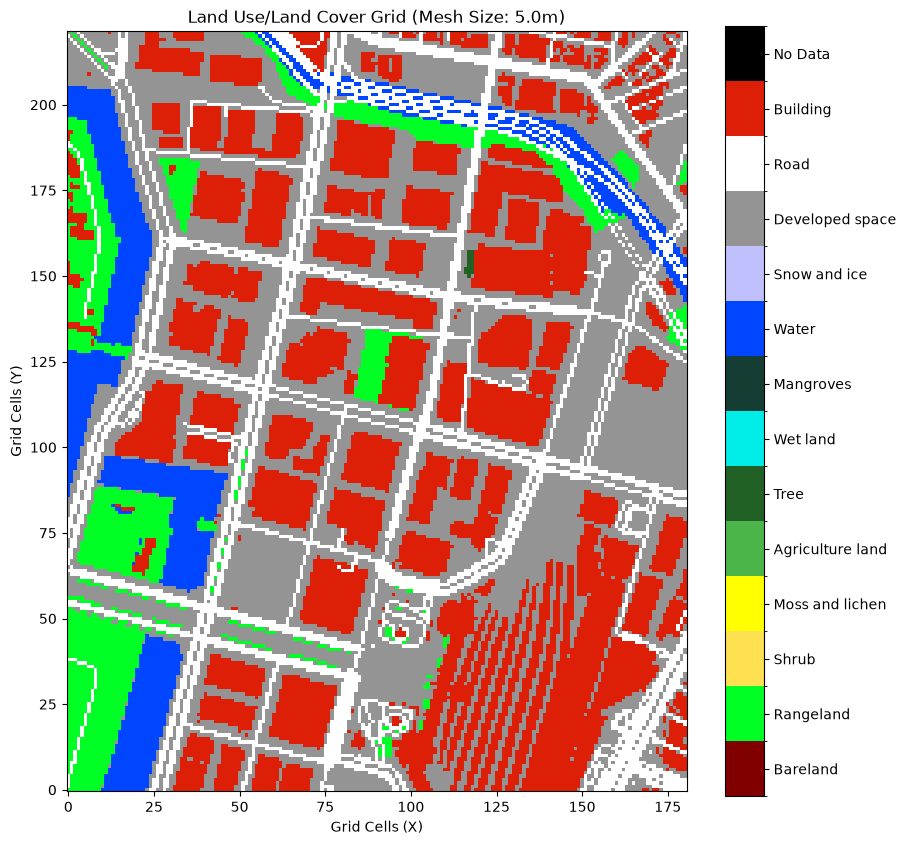

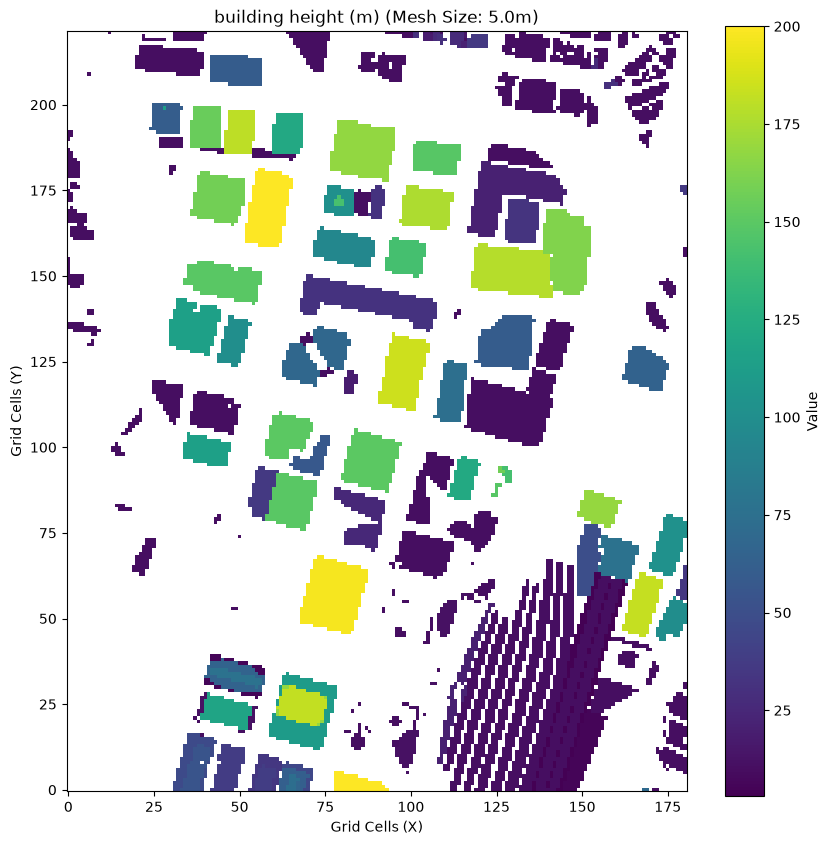

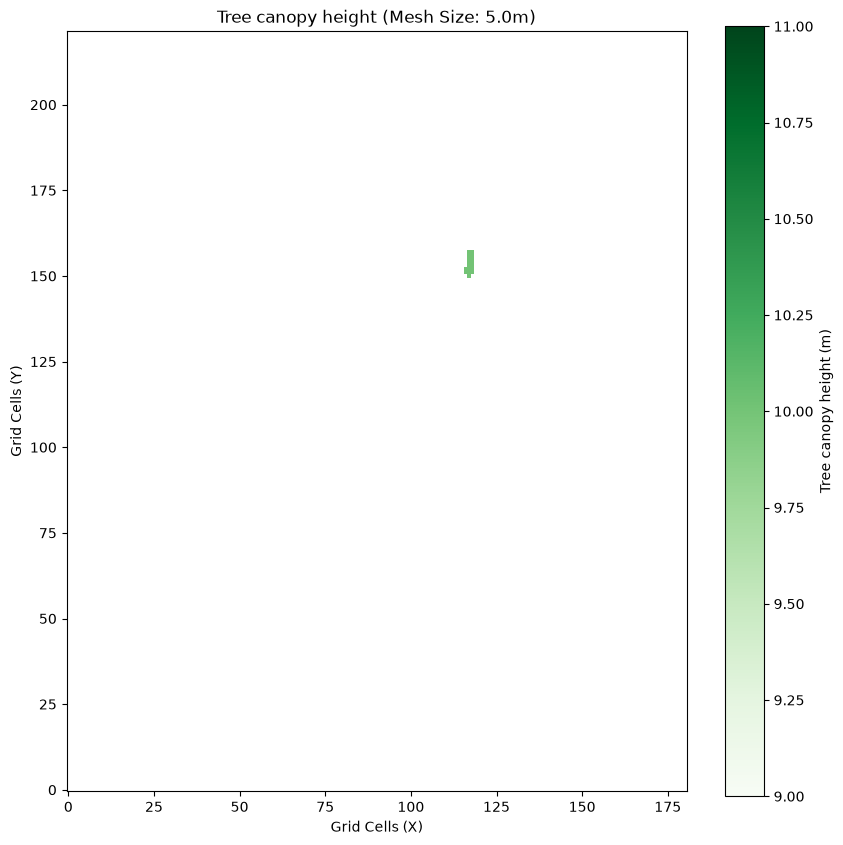

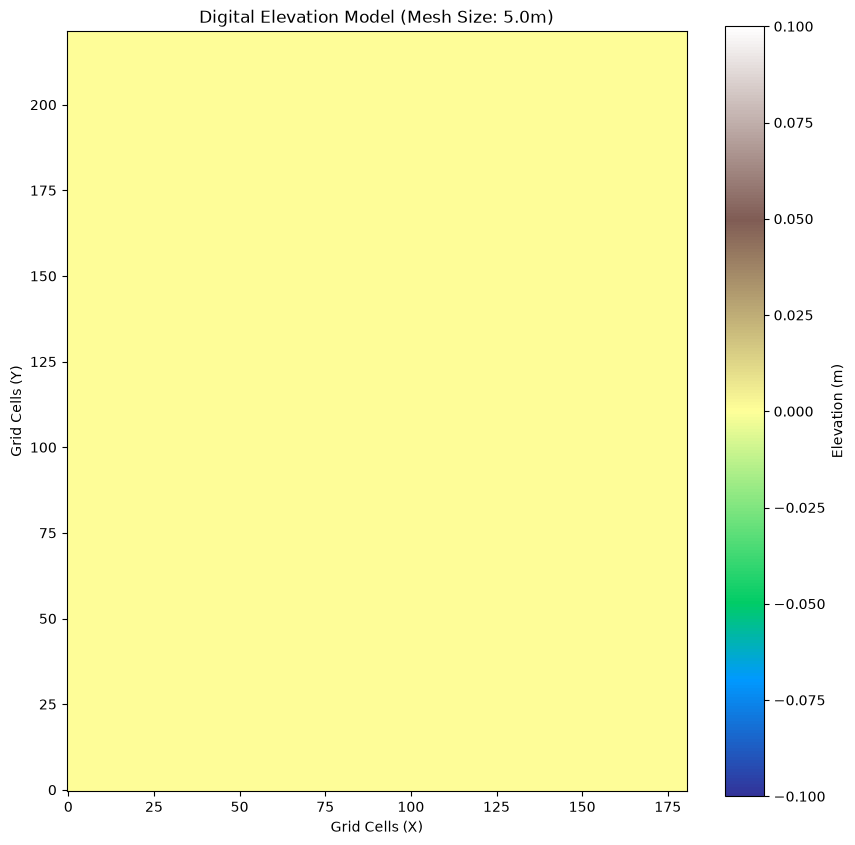

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/viz_demo/voxcity.h5


(222, 181, 41)

In [1]:
# %pip install voxcity plotly

from voxcity.generator import get_voxcity
from voxcity.exporter.obj import export_obj
from voxcity.visualizer import visualize_voxcity, visualize_voxcity_plotly

meshsize = 5
rectangle_vertices = [
    (139.760, 35.680),
    (139.760, 35.690),
    (139.770, 35.690),
    (139.770, 35.680)
]

city = get_voxcity(
    rectangle_vertices,
    meshsize=meshsize,
    building_source='OpenStreetMap',
    land_cover_source='OpenStreetMap',
    canopy_height_source='High Resolution 1m Global Canopy Height Maps',
    dem_source='DeltaDTM',
    output_dir='output/viz_demo'
)

city.voxels.classes.shape


---
## OBJ Export

Export the voxel city to Wavefront OBJ format for use in external 3D software.

**Supported software:** Blender, Rhino, SketchUp, 3ds Max, Maya, Cinema 4D

In [2]:
export_obj(city, output_dir='output/viz_demo', file_name='voxcity')
print('OBJ exported to output/viz_demo')


INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/viz_demo with the base name "voxcity".


OBJ exported to output/viz_demo


---
## Static & Interactive Visualization

### Static (PyVista)
Renders multi-view images with orthographic or perspective projection.

### Interactive (Plotly)
3D scatter plot with orbit controls for exploration in Jupyter notebooks.

In [3]:
# Multi-view static rendering (PyVista)
visualize_voxcity(
    city,
    mode="static",
    projection_type="perspective",
    distance_factor=1.2,
    output_directory="output/viz_demo"
)

# Plotly interactive figure
fig = visualize_voxcity(city, mode="interactive", show=False, return_fig=True)
fig.show()


---
## Color Mapping

VoxCity uses consistent colors for different element types:

| Type | Color | Code |
|------|-------|------|
| Building | Gray | `[128, 128, 128]` |
| Tree | Green | `[34, 139, 34]` |
| Ground | Brown | `[139, 90, 43]` |
| Water | Blue | `[0, 0, 255]` |

## Next Steps

- `demo_obj.ipynb` - Advanced OBJ export options
- `demo_envi-met.ipynb` - Export for CFD simulations